# omnisea at Bamfield

**Bamfield Marine Sciences Centre**, Barkley Sound, west coast of Vancouver Island.

Within 30 km of the station there is a DFO tide gauge (80 m away), two lighthouse climate
records, and two hydrometric gauges on nearby rivers — four different agencies' APIs, each with
its own field names, units, time conventions and paging rules.

This notebook is one query.

In [1]:
import warnings
warnings.simplefilter("ignore")

import pandas as pd
import omnisea

BAMFIELD = dict(lat=48.8353, lon=-125.1358, radius_km=30)
WEEK = ("2024-07-01", "2024-07-08")

omnisea.sources()

['cioos_metadata',
 'dfo_tides',
 'eccc_climate',
 'eccc_climate_daily',
 'eccc_hydrometric',
 'eccc_swob']

## 1. Discover — look before you download

`discover()` asks every registered source what it has, and returns a printable estimate.
Nothing is downloaded yet.

This step exists because marine queries quietly become enormous: ECCC's `climate-hourly`
collection reports **276 million rows** unfiltered. The estimate is how you find that out
*before* making the request.

In [2]:
catalog = omnisea.discover(**BAMFIELD, time=WEEK)
print(f"{len(catalog)} stations, ~{catalog.n_rows_est:,} rows estimated")
catalog.frame[["source", "station_id", "name", "distance_km", "n_rows_est"]]

10 stations, ~2,198 rows estimated


,source,station_id,name,distance_km,n_rows_est
0,dfo_tides,08545,Bamfield,0.079201,700
1,eccc_climate_daily,1031316,CAPE BEALE LIGHT,8.031310,7
2,eccc_climate_daily,1035940,PACHENA POINT,12.827256,7
3,eccc_hydrometric,08HB048,CARNATION CREEK AT THE MOUTH,13.473495,672
4,eccc_hydrometric,08HB014,SARITA RIVER NEAR BAMFIELD,13.731407,672
5,dfo_tides,08585,Effingham Bay,13.806121,28
6,dfo_tides,08556,Mutine Point,14.618219,28
7,dfo_tides,08558,Brooksby Point,19.686444,28
8,dfo_tides,08559,Head of Uchucklesit,21.118854,28
9,dfo_tides,08588,Stopper Islands,23.311803,28


The tide gauge `08545` is 80 m from the research station.

## 2. Narrow it down

`filter()` returns a new catalogue; the original is untouched. `nearest=n` works
**per site**, so a multi-location query can't return five stations at one place and none
at another.

In [3]:
nearest = catalog.filter(nearest=1)
nearest.frame[["source", "station_id", "name", "distance_km"]]

,source,station_id,name,distance_km
0,dfo_tides,08545,Bamfield,0.079201
1,eccc_climate_daily,1031316,CAPE BEALE LIGHT,8.031310
2,eccc_hydrometric,08HB048,CARNATION CREEK AT THE MOUTH,13.473495


In [4]:
# other ways to slice
{
    "within 10 km":      len(catalog.filter(max_distance_km=10)),
    "tide gauges only":  len(catalog.filter(source="dfo_tides")),
    "all ECCC datasets": len(catalog.filter(provider="eccc")),
    "has air temp":      len(catalog.filter(variables="air_temperature")),
}

{'within 10 km': 2,
 'tide gauges only': 6,
 'all ECCC datasets': 4,
 'has air temp': 2}

## 3. Fetch

Now pull it. The result is a plain `xarray.DataTree` — not a subclass, so everything in the
xarray ecosystem works on it.

In [5]:
tree = nearest.fetch()
omnisea.summary(tree)[["node", "station_name", "n_time", "start", "end"]]

,node,station_name,n_time,start,end
0,/in_situ/tides/08545,Bamfield,672,2024-07-01 00:00:00,2024-07-08 00:00:00
1,/predictions/tides_hilo/08545,Bamfield,27,2024-07-01 03:33:00,2024-07-07 22:03:00
2,/in_situ/weather_daily/1031316,CAPE BEALE LIGHT,8,2024-07-01 00:00:00,2024-07-08 00:00:00


Note the node paths. **Observations and predictions live in separate branches**:

- `/in_situ/tides/08545` — what the gauge measured
- `/predictions/tides_hilo/08545` — what the harmonic model predicts

They look identical in a flat table and are not remotely the same thing, so they never
share a node.

In [6]:
tree

<xarray.DataTree>
Group: /
│   Attributes: (12/15)
│       query_start:             2024-07-01T00:00:00+00:00
│       query_end:               2024-07-08T00:00:00+00:00
│       query_bbox:              [-125.54568384357654, 48.56550389088264, -124.72...
│       query_site_names:        48.8353,-125.1358
│       query_site_lats:         [48.8353]
│       query_site_lons:         [-125.1358]
│       ...                      ...
│       institution:             assembled by omnisea
│       source:                  omnisea multi-provider retrieval
│       history:                 2026-08-24T22:03:04+00:00 created by omnisea 0.1.0
│       omnisea_version:         0.1.0
│       n_nodes:                 3
│       n_empty_series_dropped:  1
├── Group: /in_situ
│   ├── Group: /in_situ/tides
│   │   └── Group: /in_situ/tides/08545
│   │           Dimensions:                                        (time: 672)
│   │           Coordinates:
│   │             * time                                           (time) datetime64[us] 5kB ...
│   │               latitude                                       float64 8B 48.84
│   │               longitude                                      float64 8B -125.1
│   │               station_id                                     <U5 20B '08545'
│   │               station_name                                   <U8 32B 'Bamfield'
│   │               site                                           <U17 68B '48.8353,-125.1358'
│   │           Data variables:
│   │               water_surface_height_above_reference_datum     (time) float64 5kB 2.014 ....
│   │               water_surface_height_above_reference_datum_qc  (time) object 5kB '1' ... '1'
│   │               reviewed                                       (time) int8 672B 1 1 ... 1 1
│   │           Attributes: (12/22)
│   │               Conventions:            CF-1.10
│   │               featureType:            timeSeries
│   │               source_name:            dfo_tides
│   │               institution:            Fisheries and Oceans Canada / Canadian Hydrograph...
│   │               license:                Fisheries and Oceans Canada — Open Government Lic...
│   │               references:             https://open.canada.ca/en/open-government-licence...
│   │               ...                     ...
│   │               summary:                Observed water level
│   │               datum_offset_CGVD2013:  -1.83
│   │               datum_offset_CGVD28:    -2.05
│   │               datum_offset_comment:   Offsets convert chart datum to the named vertical...
│   │               resolution:             FIFTEEN_MINUTES
│   │               distance_from_site_km:  0.079
│   └── Group: /in_situ/weather_daily
│       └── Group: /in_situ/weather_daily/1031316
│               Dimensions:                 (time: 8)
│               Coordinates:
│                 * time                    (time) datetime64[us] 64B 2024-07-01 ... 2024-07-08
│                   latitude                float64 8B 48.79
│                   longitude               float64 8B -125.2
│                   station_id              <U7 28B '1031316'
│                   station_name            <U16 64B 'CAPE BEALE LIGHT'
│                   site                    <U17 68B '48.8353,-125.1358'
│               Data variables:
│                   air_temperature         (time) float64 64B 14.0 14.0 13.8 ... 14.8 17.8 15.8
│                   air_temperature_min     (time) float64 64B 11.5 11.0 11.0 ... 4.0 13.5 11.5
│                   air_temperature_max     (time) float64 64B 16.5 17.0 16.5 ... 25.5 22.0 20.0
│                   precipitation_amount    (time) float64 64B 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0
│                   rainfall_amount         (time) float64 64B 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0
│                   snowfall_amount         (time) float64 64B 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0
│                   surface_snow_thickness  (time) float64 64B 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0

## 4. Provenance travels with the data

Every node carries its institution, licence, source URL and vertical datum — including the
offsets needed to convert chart datum to CGVD2013 or CGVD28.

In [7]:
tides = tree["/in_situ/tides/08545"].dataset
{k: tides.attrs[k] for k in
 ["institution", "license", "datum", "datum_offset_CGVD2013", "resolution", "source_url"]}

{'institution': 'Fisheries and Oceans Canada / Canadian Hydrographic Service',
 'license': 'Fisheries and Oceans Canada — Open Government Licence – Canada',
 'datum': 'chart datum (CD)',
 'datum_offset_CGVD2013': -1.83,
 'resolution': 'FIFTEEN_MINUTES',
 'source_url': 'https://api-iwls.dfo-mpo.gc.ca/api/v1/stations/5cebf1e23d0f4a073c4bc062/data?time-series-code=wlo'}

## 5. Nothing is silently dropped or rescaled

Fields with a CF equivalent are renamed and described. Fields without one still travel,
under the provider's own name, tagged `omnisea_mapped = 0`. QC flags are kept as `<var>_qc`.

In [8]:
mapped, carried, flags = [], [], []
for node in tree.subtree:
    for name, var in node.dataset.data_vars.items():
        target = (flags if str(name).endswith("_qc")
                  else carried if var.attrs.get("omnisea_mapped") == 0
                  else mapped)
        target.append(str(name))

pd.DataFrame({
    "kind": ["CF-named", "carried as published", "QC flags"],
    "n": [len(set(mapped)), len(set(carried)), len(set(flags))],
    "example": [sorted(set(mapped))[0], sorted(set(carried))[0], sorted(set(flags))[0]],
})

,kind,n,example
0,CF-named,11,air_temperature
1,carried as published,1,reviewed
2,QC flags,2,water_surface_height_above_reference_datum_at_...


In [9]:
# units describe what the values ACTUALLY are — conversion is opt-in
air = tree["/in_situ/weather_daily/1031316"].dataset["air_temperature"]
print("units    :", air.attrs["units"])
print("cf_units :", air.attrs["cf_units"], "->  pass to_cf_units=True")
print("note     :", air.attrs["note"])

units    : degC
cf_units : K ->  pass to_cf_units=True
note     : values are in provider units (degC); pass to_cf_units=True for K


Encoding *repairs* are different, and always applied: ECCC ships wind direction in
tens of degrees, so a raw `25` means 250°. That's a storage encoding, not a unit choice —
leaving it raw would simply be wrong.

## 6. Tidy frame for analysis

The tree is the lossless container. `to_dataframe()` is the convenience view — long format,
because stations have different variables and different sampling rates.

In [10]:
frame = omnisea.to_dataframe(tree)
frame.head(6)[["time", "station_id", "variable", "value"]]

,time,station_id,variable,value
0,2024-07-01,08545,reviewed,1.000
1,2024-07-01,08545,water_surface_height_above_reference_datum,2.014
2,2024-07-01,1031316,air_temperature,14.000
3,2024-07-01,1031316,air_temperature_max,16.500
4,2024-07-01,1031316,air_temperature_min,11.500
5,2024-07-01,1031316,cooling_degree_days,0.000


## 7. Does it actually behave like the ocean?

Parsing correctly is not the same as being right. Barkley Sound is semidiurnal, so the
observed series should show about two highs a day — and the *independently fetched*
predicted extrema should land on the observed peaks.

In [11]:
wlo = tides["water_surface_height_above_reference_datum"].to_series()
hilo = tree["/predictions/tides_hilo/08545"].dataset[
    "water_surface_height_above_reference_datum_at_extremum"].to_series()

v = wlo.values
is_peak = (v[1:-1] > v[:-2]) & (v[1:-1] >= v[2:])
days = (wlo.index[-1] - wlo.index[0]) / pd.Timedelta(days=1)
peak_times = wlo.index[1:-1][is_peak]

highs = hilo[hilo > hilo.median()]
offsets = [min(abs((p - h).total_seconds()) / 60 for p in peak_times) for h in highs.index]
interp = wlo.reindex(wlo.index.union(hilo.index)).interpolate().reindex(hilo.index)

print(f"range              : {v.min():.2f} to {v.max():.2f} m above chart datum")
print(f"highs per day      : {is_peak.sum()/days:.2f}   (semidiurnal expects ~2)")
print(f"predicted vs peaks : median {pd.Series(offsets).median():.0f} min offset")
print(f"height agreement   : mean |diff| {(interp-hilo).abs().mean():.3f} m, r={interp.corr(hilo):.4f}")

range              : 0.07 to 3.40 m above chart datum
highs per day      : 2.14   (semidiurnal expects ~2)
predicted vs peaks : median 5 min offset
height agreement   : mean |diff| 0.060 m, r=0.9994


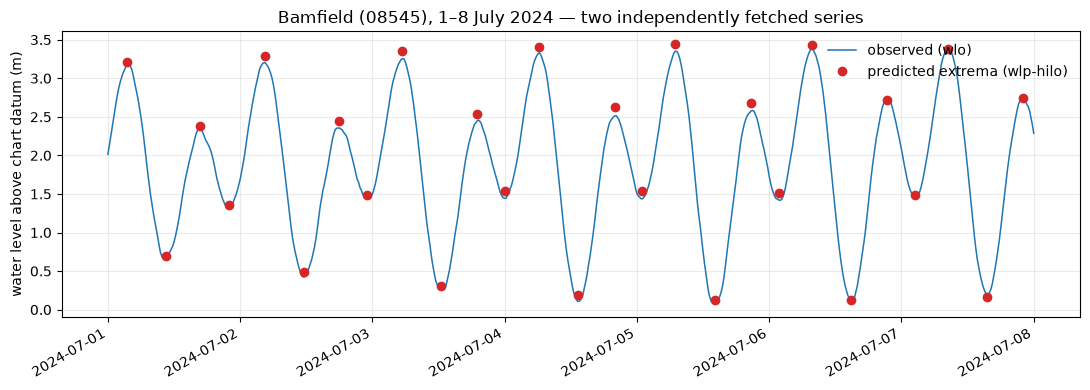

In [12]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(wlo.index, wlo.values, lw=1.1, label="observed (wlo)", color="#1f77b4")
ax.plot(hilo.index, hilo.values, "o", ms=6, label="predicted extrema (wlp-hilo)",
        color="#d62728", zorder=3)
ax.set_ylabel("water level above chart datum (m)")
ax.set_title("Bamfield (08545), 1–8 July 2024 — two independently fetched series")
ax.legend(loc="upper right", frameon=False)
ax.grid(alpha=0.25)
fig.autofmt_xdate()
plt.tight_layout()

The red dots sit on the peaks and troughs of the blue line. That agreement is the real
end-to-end check: it means the times, the units *and* the datum are all right — not merely
parseable.

## 8. Many locations at once

Pass a list of sites — `Site` objects, `(lat, lon, name)` tuples, dicts, or a DataFrame with
`lat`/`lon` columns, so a CSV of moorings works directly.

Locations with no nearby data contribute nothing. That's normal, not an error — and
`coverage()` reports **every site you asked for**, so the gaps are visible rather than
inferred from an absence.

In [13]:
sites = [
    {"name": "Bamfield",   "lat": 48.8353, "lon": -125.1358},
    {"name": "Tofino",     "lat": 49.1530, "lon": -125.9066},
    {"name": "Victoria",   "lat": 48.4204, "lon": -123.3656},
    {"name": "Open ocean", "lat": 47.5000, "lon": -128.5000},   # deliberately empty
]

multi = omnisea.positions(sites, radius_km=15, time=WEEK, providers="dfo_tides", nearest=1)
omnisea.coverage(multi)

,site,n_nodes,n_time,providers,has_data
0,Bamfield,2,699,dfo,True
1,Tofino,2,700,dfo,True
2,Victoria,2,691,dfo,True
3,Open ocean,0,0,,False


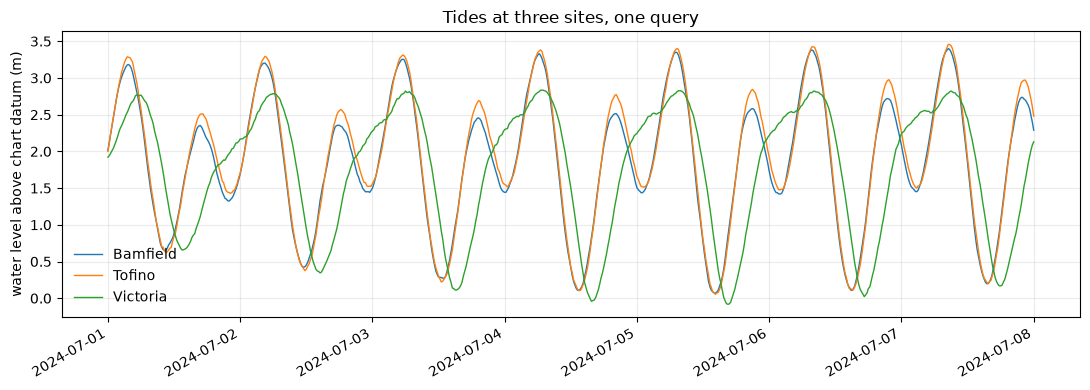

In [14]:
# your own site labels come back on the data, ready to join
tidy = omnisea.to_dataframe(multi)
obs = tidy[tidy["variable"] == "water_surface_height_above_reference_datum"]

fig, ax = plt.subplots(figsize=(11, 4))
for site, group in obs.groupby("site"):
    ax.plot(group["time"], group["value"], lw=1.0, label=site)
ax.set_ylabel("water level above chart datum (m)")
ax.set_title("Tides at three sites, one query")
ax.legend(frameon=False)
ax.grid(alpha=0.25)
fig.autofmt_xdate()
plt.tight_layout()

Different tidal ranges and phases along the coast — Barkley Sound versus the Strait of
Juan de Fuca — from a single call.

## 9. Save it

`DataTree.to_netcdf()` works natively via netCDF4 groups. The structure round-trips.

In [15]:
import xarray as xr

tree.to_netcdf("bamfield.nc")
reopened = xr.open_datatree("bamfield.nc")
[n.path for n in reopened.subtree if n.dataset.data_vars]

['/in_situ/tides/08545',
 '/in_situ/weather_daily/1031316',
 '/predictions/tides_hilo/08545']

---

## Adding your own source

A new data source is **one new file**, not a refactor — see
[`docs/adding-a-provider.md`](../docs/adding-a-provider.md) and the worked example in
[`examples/csv_stations.py`](csv_stations.py).

Ship it as a package with an entry point and it's indexed automatically:

```toml
[project.entry-points."omnisea.providers"]
my_org = "my_package.provider:MyOrgProvider"
```